In [3]:
from google.colab import drive

# اتصال به گوگل درایو
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [7]:
# مرحله ۱: تنظیم محیط و تقسیم داده‌ها

# ایمپورت‌های لازم
from google.colab import drive
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm



# مسیرهای فایل‌ها
base_path = '/content/drive/MyDrive/Fum/term9/Project_phase2'
labels_csv = os.path.join(base_path, 'labels.csv')
train_csv = os.path.join(base_path, 'train.csv')
validation_csv = os.path.join(base_path, 'validation.csv')
test_csv = os.path.join(base_path, 'test.csv')

# خواندن فایل labels.csv
print("خواندن فایل labels.csv...")
df = pd.read_csv(labels_csv)

# تقسیم داده‌ها به train (70%)، validation (15%) و test (15%)
print("تقسیم داده‌ها...")
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# ذخیره فایل‌های CSV
print("ذخیره فایل‌های train.csv، validation.csv و test.csv...")
train_df.to_csv(train_csv, index=False)
val_df.to_csv(validation_csv, index=False)
test_df.to_csv(test_csv, index=False)

# لاگ‌گیری تعداد داده‌ها
print("لاگ‌گیری تعداد داده‌ها:")
print(f"تعداد کل داده‌ها: {len(df)}")
print(f"تعداد داده‌های train: {len(train_df)} ({len(train_df)/len(df)*100:.2f}%)")
print(f"تعداد داده‌های validation: {len(val_df)} ({len(val_df)/len(df)*100:.2f}%)")
print(f"تعداد داده‌های test: {len(test_df)} ({len(test_df)/len(df)*100:.2f}%)")

خواندن فایل labels.csv...
تقسیم داده‌ها...
ذخیره فایل‌های train.csv، validation.csv و test.csv...
لاگ‌گیری تعداد داده‌ها:
تعداد کل داده‌ها: 3151
تعداد داده‌های train: 2205 (69.98%)
تعداد داده‌های validation: 473 (15.01%)
تعداد داده‌های test: 473 (15.01%)


In [8]:
# تست کیس برای مرحله ۱
import pandas as pd
import os
from tqdm import tqdm

# مسیرهای فایل‌ها
base_path = '/content/drive/MyDrive/Fum/term9/Project_phase2'
labels_csv = os.path.join(base_path, 'labels.csv')
train_csv = os.path.join(base_path, 'train.csv')
validation_csv = os.path.join(base_path, 'validation.csv')
test_csv = os.path.join(base_path, 'test.csv')

# تابع بررسی فایل‌ها
def run_tests():
    tests = [
        ("چک کردن وجود فایل train.csv", lambda: os.path.exists(train_csv)),
        ("چک کردن وجود فایل validation.csv", lambda: os.path.exists(validation_csv)),
        ("چک کردن وجود فایل test.csv", lambda: os.path.exists(test_csv)),
        ("چک کردن ستون‌های train.csv", lambda: set(pd.read_csv(train_csv).columns) == {'image', 'plate'}),
        ("چک کردن ستون‌های validation.csv", lambda: set(pd.read_csv(validation_csv).columns) == {'image', 'plate'}),
        ("چک کردن ستون‌های test.csv", lambda: set(pd.read_csv(test_csv).columns) == {'image', 'plate'}),
        ("چک کردن عدم وجود داده تکراری", lambda: len(set(pd.read_csv(train_csv)['image']).intersection(
            set(pd.read_csv(validation_csv)['image']), set(pd.read_csv(test_csv)['image']))) == 0),
    ]

    # خواندن تعداد کل داده‌ها
    df = pd.read_csv(labels_csv)
    total_count = len(df)
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(validation_csv)
    test_df = pd.read_csv(test_csv)

    # چک کردن نسبت‌های تقسیم
    train_ratio = len(train_df) / total_count
    val_ratio = len(val_df) / total_count
    test_ratio = len(test_df) / total_count
    tests.append(("چک کردن نسبت train (حدود 70%)", lambda: 0.68 <= train_ratio <= 0.72))
    tests.append(("چک کردن نسبت validation (حدود 15%)", lambda: 0.13 <= val_ratio <= 0.17))
    tests.append(("چک کردن نسبت test (حدود 15%)", lambda: 0.13 <= test_ratio <= 0.17))

    # اجرای تست‌ها با پروگرس بار
    print("اجرای تست‌ها...")
    passed = 0
    total = len(tests)
    for i, (test_name, test_func) in enumerate(tqdm(tests, desc="پیشرفت تست‌ها")):
        try:
            if test_func():
                print(f"تست '{test_name}' پاس شد.")
                passed += 1
            else:
                print(f"تست '{test_name}' شکست خورد!")
        except Exception as e:
            print(f"خطا در تست '{test_name}': {e}")

    # گزارش پیشرفت
    print(f"\nنتایج تست: {passed}/{total} تست پاس شد ({passed/total*100:.2f}%)")

# اجرای تست‌ها
run_tests()

اجرای تست‌ها...


پیشرفت تست‌ها: 100%|██████████| 10/10 [00:00<00:00, 399.25it/s]

تست 'چک کردن وجود فایل train.csv' پاس شد.
تست 'چک کردن وجود فایل validation.csv' پاس شد.
تست 'چک کردن وجود فایل test.csv' پاس شد.
تست 'چک کردن ستون‌های train.csv' پاس شد.
تست 'چک کردن ستون‌های validation.csv' پاس شد.
تست 'چک کردن ستون‌های test.csv' پاس شد.
تست 'چک کردن عدم وجود داده تکراری' پاس شد.
تست 'چک کردن نسبت train (حدود 70%)' پاس شد.
تست 'چک کردن نسبت validation (حدود 15%)' پاس شد.
تست 'چک کردن نسبت test (حدود 15%)' پاس شد.

نتایج تست: 10/10 تست پاس شد (100.00%)


In [9]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

# مسیرهای فایل‌ها
base_path = '/content/drive/MyDrive/Fum/term9/Project_phase2'
dataset_path = os.path.join(base_path, 'dataset2_grayscale')
labels_csv = os.path.join(base_path, 'labels.csv')

# تابع بررسی سایز تصاویر
def test_image_sizes():
    # خواندن فایل labels.csv
    print("خواندن فایل labels.csv...")
    df = pd.read_csv(labels_csv)
    image_files = df['image'].tolist()

    # انتظار داریم سایز تصاویر 128x64 باشه
    expected_size = (128, 64)
    size_mismatch = []
    sizes_found = set()

    # پروگرس بار برای بررسی تصاویر
    print("بررسی سایز تصاویر...")
    for i, image_file in enumerate(tqdm(image_files, desc="پیشرفت بررسی تصاویر")):
        try:
            image_path = os.path.join(dataset_path, image_file)
            if not os.path.exists(image_path):
                print(f"خطا: فایل {image_file} یافت نشد!")
                continue
            with Image.open(image_path) as img:
                img_size = img.size  # (width, height)
                sizes_found.add(img_size)
                if img_size != expected_size:
                    size_mismatch.append((image_file, img_size))
        except Exception as e:
            print(f"خطا در پردازش {image_file}: {e}")

    # تست‌ها
    tests = [
        ("چک کردن وجود همه فایل‌های تصویر", lambda: len(size_mismatch) == 0),
        ("چک کردن یکسان بودن سایز همه تصاویر", lambda: len(sizes_found) == 1),
        ("چک کردن برابر بودن سایز با 128x64", lambda: expected_size in sizes_found),
    ]

    # اجرای تست‌ها با پروگرس بار
    print("\nاجرای تست‌ها...")
    passed = 0
    total = len(tests)
    for i, (test_name, test_func) in enumerate(tqdm(tests, desc="پیشرفت تست‌ها")):
        try:
            if test_func():
                print(f"تست '{test_name}' پاس شد.")
                passed += 1
            else:
                print(f"تست '{test_name}' شکست خورد!")
        except Exception as e:
            print(f"خطا در تست '{test_name}': {e}")

    # لاگ‌گیری سایزهای یافت‌شده
    print("\nلاگ سایزهای تصاویر:")
    print(f"سایزهای یافت‌شده: {sizes_found}")
    if size_mismatch:
        print("تصاویری با سایز غیرمنتظره:")
        for img, size in size_mismatch:
            print(f"فایل {img}: سایز {size}")
    else:
        print("همه تصاویر سایز یکسان و برابر با 128x64 دارند.")

    # گزارش پیشرفت
    print(f"\nنتایج تست: {passed}/{total} تست پاس شد ({passed/total*100:.2f}%)")

# اجرای تست‌ها
test_image_sizes()

خواندن فایل labels.csv...
بررسی سایز تصاویر...


پیشرفت بررسی تصاویر:   0%|          | 13/3151 [00:12<50:32,  1.03it/s]


KeyboardInterrupt: 

In [10]:
!cp -r /content/drive/MyDrive/Fum/term9/Project_phase2/* /content

In [57]:
%%writefile /content/dataloader.py
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import json
import os

# مسیرهای داده
data_root = '/content/dataset2_grayscale'
train_csv = '/content/train.csv'
val_csv = '/content/validation.csv'
test_csv = '/content/test.csv'
vocab_path = '/content/vocab.json'

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)

# تبدیل‌ها
train_transform = transforms.Compose([
    transforms.Resize((64, 128)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.GaussianBlur(kernel_size=5, sigma=0.5),
    transforms.RandomAffine(degrees=0, shear=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# دیتاست
class PlateDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.df.iloc[idx, 0])  # ستون اول: مسیر تصویر
        image = Image.open(img_name).convert('L')  # خاکستری
        label = self.df.iloc[idx, 1]  # ستون دوم: لیبل

        # کد کردن لیبل
        label_encoded = [vocab[char] for char in label]
        label_encoded = torch.tensor(label_encoded, dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, label_encoded

# دیتالودرها
train_dataset = PlateDataset(train_csv, data_root, transform=train_transform)
val_dataset = PlateDataset(val_csv, data_root, transform=val_transform)
test_dataset = PlateDataset(test_csv, data_root, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

Overwriting /content/dataloader.py


In [49]:
if 'model' in sys.modules:
    del sys.modules['model']

In [50]:
%%writefile /content/model.py
import torch
import torch.nn as nn

# ماژول برای چاپ شکل خروجی
class PrintShape(nn.Module):
    def __init__(self, layer_name):
        super(PrintShape, self).__init__()
        self.layer_name = layer_name

    def forward(self, x):
        #print(f"شکل خروجی بعد از لایه {self.layer_name}: {x.shape}")
        return x

class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super(CRNN, self).__init__()

        # لایه‌های کانولوشنی با دراپ‌اوت و چاپ شکل
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # ورودی: (1, 64, 128) -> خروجی: (64, 64, 128)
            PrintShape("Conv1"),
            nn.ReLU(True),
            PrintShape("ReLU1"),
            nn.Dropout2d(0.3),
            PrintShape("Dropout1"),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (64, 32, 64)
            PrintShape("MaxPool1"),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (128, 32, 64)
            PrintShape("Conv2"),
            nn.ReLU(True),
            PrintShape("ReLU2"),
            nn.Dropout2d(0.3),
            PrintShape("Dropout2"),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (128, 16, 32)
            PrintShape("MaxPool2"),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # (256, 16, 32)
            PrintShape("Conv3"),
            nn.ReLU(True),
            PrintShape("ReLU3"),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # (256, 16, 32)
            PrintShape("Conv4"),
            nn.ReLU(True),
            PrintShape("ReLU4"),
            nn.Dropout2d(0.3),
            PrintShape("Dropout3"),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (256, 8, 16)
            PrintShape("MaxPool3"),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),  # (512, 8, 16)
            PrintShape("Conv5"),
            nn.ReLU(True),
            PrintShape("ReLU5"),
            nn.BatchNorm2d(512),
            PrintShape("BatchNorm"),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),  # (512, 8, 16)
            PrintShape("Conv6"),
            nn.ReLU(True),
            PrintShape("ReLU6"),
            nn.Dropout2d(0.3),
            PrintShape("Dropout4"),
            nn.MaxPool2d(kernel_size=(4, 1)),  # (512, 2, 16)
            PrintShape("MaxPool4"),
            nn.Conv2d(512, 512, kernel_size=2, stride=1),  # (512, 1, 15)
            PrintShape("Conv7"),
            nn.ReLU(True),
            PrintShape("ReLU7")
        )

        # دراپ‌اوت قبل از RNN
        self.dropout_rnn = nn.Dropout(0.2)

        # لایه‌های بازگشتی
        self.rnn = nn.Sequential(
            nn.LSTM(input_size=512, hidden_size=hidden_size, num_layers=2,
                    bidirectional=True, batch_first=True)
        )

        # لایه خروجی
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (batch_size, 1, 64, 128)
        conv = self.cnn(x)  # (batch_size, 512, 1, 15)
        #print(f"شکل خروجی نهایی CNN: {conv.shape}")
        batch_size, channels, height, width = conv.size()
        conv = conv.squeeze(2)  # (batch_size, 512, 15)
        #print(f"شکل بعد از squeeze: {conv.shape}")
        conv = conv.permute(0, 2, 1)  # (batch_size, 15, 512)
        #print(f"شکل بعد از permute: {conv.shape}")
        conv = self.dropout_rnn(conv)
        #print(f"شکل بعد از dropout_rnn: {conv.shape}")
        rnn_out, _ = self.rnn(conv)  # (batch_size, 15, hidden_size*2)
        #print(f"شکل بعد از RNN: {rnn_out.shape}")
        out = self.fc(rnn_out)  # (batch_size, 15, num_classes)
        #print(f"شکل خروجی نهایی: {out.shape}")
        return out

Overwriting /content/model.py


In [51]:
import torch
from model import CRNN
from dataloader import train_loader, vocab

# لود مدل
model = CRNN(num_classes=len(vocab)).cuda()
model.eval()

# تست یک دسته
for images, labels in train_loader:
    images = images.cuda()
    print("شکل ورودی:", images.shape)  # باید [batch_size, 1, 64, 128] باشد
    output = model(images)
    print("شکل خروجی:", output.shape)  # باید [batch_size, 15, num_classes] باشد
    break

شکل ورودی: torch.Size([8, 1, 64, 128])
شکل خروجی: torch.Size([8, 15, 35])


In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from model import CRNN
from tqdm import tqdm
import json
import os
import sys
sys.path.append('/content/drive/MyDrive/Fum/term9/Project_phase2')
from dataloader import train_loader, val_loader

# تنظیمات
num_classes = 35
hidden_size = 256
batch_size = 8
max_epochs = 200
learning_rate = 0.0002
weight_decay = 0.0001  # L2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"دستگاه Training: {device}")

# لود وکبیولری
vocab_path = '/content/vocab.json'
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# مدل
model = CRNN(num_classes, hidden_size).to(device)

# لاس و اپتیمایزر
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early Stopping
patience = 20
best_val_loss = float('inf')
patience_counter = 0
best_model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth"

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)  # (batch_size, seq_length)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:  # حذف blank و تکراری
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
                else:
                    print(f"ایندکس نامعتبر: {idx}")
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# تابع محاسبه دقت
def compute_accuracy(model, loader, reverse_vocab):
    model.eval()
    total_correct_plates = 0
    total_correct_chars = 0
    total_chars = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).softmax(2)

            decoded_preds = decode_predictions(outputs, reverse_vocab)

            for i in range(labels.size(0)):
                label = labels[i].cpu().numpy()
                gt = ''.join([reverse_vocab[idx] for idx in label if idx in reverse_vocab])
                pred = decoded_preds[i]

                # دقت پلاک
                if pred == gt:
                    total_correct_plates += 1

                # دقت کاراکتر
                min_len = min(len(pred), len(gt))
                correct_chars = sum(1 for p, g in zip(pred[:min_len], gt[:min_len]) if p == g)
                total_correct_chars += correct_chars
                total_chars += len(gt)

                total_samples += 1

    plate_accuracy = total_correct_plates / total_samples * 100
    char_accuracy = total_correct_chars / total_chars * 100
    return plate_accuracy, char_accuracy

# تابع آموزش
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc="آموزش"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).log_softmax(2)
        batch_size = images.size(0)

        input_lengths = torch.full((batch_size,), outputs.size(1), dtype=torch.long)  # seq_length=15
        target_lengths = torch.full((batch_size,), 8, dtype=torch.long)  # لیبل ۸ کاراکتری

        loss = criterion(outputs.permute(1, 0, 2), labels, input_lengths, target_lengths)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"invalid loss: {loss.item()}")
            continue

        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

    return total_loss / len(loader)

# تابع ارزیابی
def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="ارزیابی"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).log_softmax(2)
            batch_size = images.size(0)
            input_lengths = torch.full((batch_size,), outputs.size(1), dtype=torch.long)
            target_lengths = torch.full((batch_size,), 8, dtype=torch.long)
            loss = criterion(outputs.permute(1, 0, 2), labels, input_lengths, target_lengths)
            total_loss += loss.item()

    return total_loss / len(loader)

# حلقه آموزش
for epoch in range(max_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_epoch(model, val_loader, criterion)

    # محاسبه دقت
    train_plate_acc, train_char_acc = compute_accuracy(model, train_loader, reverse_vocab)
    val_plate_acc, val_char_acc = compute_accuracy(model, val_loader, reverse_vocab)

    print(f"Epoch {epoch+1}/{max_epochs}:")
    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Train Plate Accuracy: {train_plate_acc:.2f}%, Train Char Accuracy: {train_char_acc:.2f}%")
    print(f"Val Plate Accuracy: {val_plate_acc:.2f}%, Val Char Accuracy: {val_char_acc:.2f}%")

    # Scheduler
    scheduler.step(val_loss)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"مدل ذخیره شد: {best_model_path}")
    else:
        patience_counter += 1
        print(f"بدون بهبود: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early Stopping!")
            break

print("آموزش تمام شد!")

دستگاه Training: cuda


ارزیابی: 100%|██████████| 60/60 [00:00<00:00, 106.78it/s]


Epoch 1/200:
Train Loss: 2.8119, Val Loss: 2.6326, LR: 0.000200
Train Plate Accuracy: 0.00%, Train Char Accuracy: 2.91%
Val Plate Accuracy: 0.00%, Val Char Accuracy: 2.38%
مدل ذخیره شد: /content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth


ارزیابی: 100%|██████████| 60/60 [00:00<00:00, 110.41it/s]


Epoch 2/200:
Train Loss: 2.5178, Val Loss: 2.3893, LR: 0.000200
Train Plate Accuracy: 0.00%, Train Char Accuracy: 7.77%
Val Plate Accuracy: 0.00%, Val Char Accuracy: 8.09%
مدل ذخیره شد: /content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth


...

Epoch 56/200:
Train Loss: 0.0210, Val Loss: 0.1242, LR: 0.000025
Train Plate Accuracy: 98.32%, Train Char Accuracy: 99.71%
Val Plate Accuracy: 87.10%, Val Char Accuracy: 96.83%
بدون بهبود: 18/20


ارزیابی: 100%|██████████| 60/60 [00:00<00:00, 106.23it/s]


Epoch 57/200:
Train Loss: 0.0199, Val Loss: 0.1230, LR: 0.000013
Train Plate Accuracy: 98.64%, Train Char Accuracy: 99.79%
Val Plate Accuracy: 86.89%, Val Char Accuracy: 96.80%
بدون بهبود: 19/20


ارزیابی: 100%|██████████| 60/60 [00:00<00:00, 100.36it/s]


Epoch 58/200:
Train Loss: 0.0192, Val Loss: 0.1250, LR: 0.000013
Train Plate Accuracy: 98.59%, Train Char Accuracy: 99.74%
Val Plate Accuracy: 87.10%, Val Char Accuracy: 96.67%
بدون بهبود: 20/20
Early Stopping!
آموزش تمام شد!


In [68]:
def evaluate_model(model, loader, reverse_vocab):
    total_correct_plates = 0
    total_samples = 0
    total_chars = 0
    total_correct_chars = 0
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="ارزیابی تست"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # (B, T, C)
            outputs = outputs.softmax(2)
            decoded_preds = decode_predictions(outputs, reverse_vocab)

            for i in range(labels.size(0)):
                label = labels[i].cpu().numpy()
                gt = ''.join([reverse_vocab[idx] for idx in label if idx in reverse_vocab])
                pred = decoded_preds[i]

                predictions.append(pred)
                ground_truths.append(gt)

                # دقت روی پلاک کامل
                if pred == gt:
                    total_correct_plates += 1
                total_samples += 1

                # دقت کاراکتری
                correct_chars = sum([1 for a, b in zip(gt, pred) if a == b])
                total_correct_chars += correct_chars
                total_chars += len(gt)

    plate_accuracy = total_correct_plates / total_samples * 100
    char_accuracy = total_correct_chars / total_chars * 100

    return plate_accuracy, char_accuracy, predictions, ground_truths


In [69]:
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import json
import os

# مسیرهای داده
data_root = '/content/dataset2_grayscale'
train_csv = '/content/train.csv'
val_csv = '/content/validation.csv'
test_csv = '/content/test.csv'
vocab_path = '/content/vocab.json'

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)

# تبدیل‌ها
train_transform = transforms.Compose([
    transforms.Resize((64, 128)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.GaussianBlur(kernel_size=5, sigma=0.5),
    transforms.RandomAffine(degrees=0, shear=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# دیتاست
class PlateDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.df.iloc[idx, 0])  # ستون اول: مسیر تصویر
        image = Image.open(img_name).convert('L')  # خاکستری
        label = self.df.iloc[idx, 1]  # ستون دوم: لیبل

        # کد کردن لیبل
        label_encoded = [vocab[char] for char in label]
        label_encoded = torch.tensor(label_encoded, dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, label_encoded

# دیتالودرها
train_dataset = PlateDataset(train_csv, data_root, transform=train_transform)
val_dataset = PlateDataset(val_csv, data_root, transform=val_transform)
test_dataset = PlateDataset(test_csv, data_root, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

In [70]:
plate_acc, char_acc, predictions, ground_truths = evaluate_model(model, test_loader, reverse_vocab)

print(f"\n دقت پلاک کامل: {plate_acc:.2f}%")
print(f" دقت کاراکتری: {char_acc:.2f}%")


ارزیابی تست: 100%|██████████| 60/60 [00:00<00:00, 84.68it/s]


 دقت پلاک کامل: 86.05%
 دقت کاراکتری: 96.33%


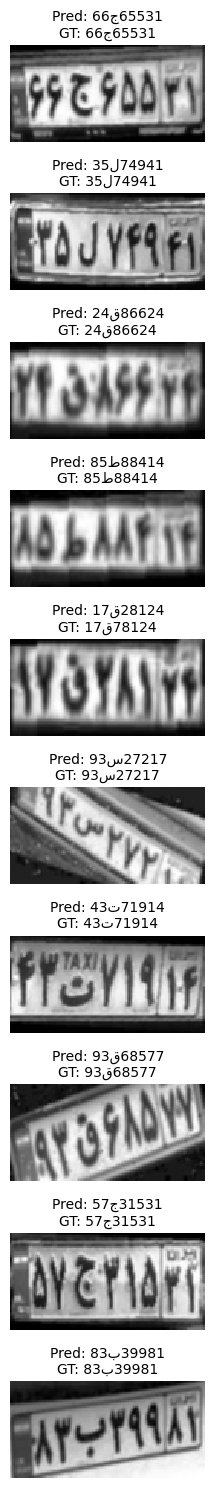

In [71]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import sys
import json
sys.path.append('/content')
from dataloader import test_loader, test_dataset
from model import CRNN

# تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 35
hidden_size = 256
model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3.pth"
vocab_path = "/content/vocab.json"

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# لود مدل
model = CRNN(num_classes, hidden_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:  # حذف بلنک و تکراری‌ها
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# انتخاب 10 نمونه رندوم
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)
images = []
labels = []
predictions = []

# پردازش نمونه‌ها
with torch.no_grad():
    for idx in indices:
        image, label = test_dataset[idx]
        images.append(image)
        # گرندتروث
        label_str = ''.join([reverse_vocab[idx.item()] for idx in label if idx.item() in reverse_vocab])
        labels.append(label_str)
        # پیش‌بینی
        image = image.unsqueeze(0).to(device)  # اضافه کردن بچ دایمنشن
        output = model(image).softmax(2)
        pred = decode_predictions(output, reverse_vocab)[0]
        predictions.append(pred)


# نمایش تصاویر و اطلاعات
fig, axes = plt.subplots(num_samples, 1, figsize=(5, num_samples * 1.5))  # هر تصویر 1.5 اینچ ارتفاع
if num_samples == 1:
    axes = [axes]  # برای یه تصویر، axes رو لیست کنیم
else:
    axes = axes.ravel()

for i in range(num_samples):
    img = images[i].squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    axes[i].imshow(img, cmap='gray', interpolation='none', aspect='equal')
    axes[i].set_title(f"Pred: {predictions[i]}\nGT: {labels[i]}", fontsize=10)
    axes[i].axis('off')
    axes[i].set_xlim(0, 128)
    axes[i].set_ylim(64, 0)

plt.tight_layout()
plt.show()

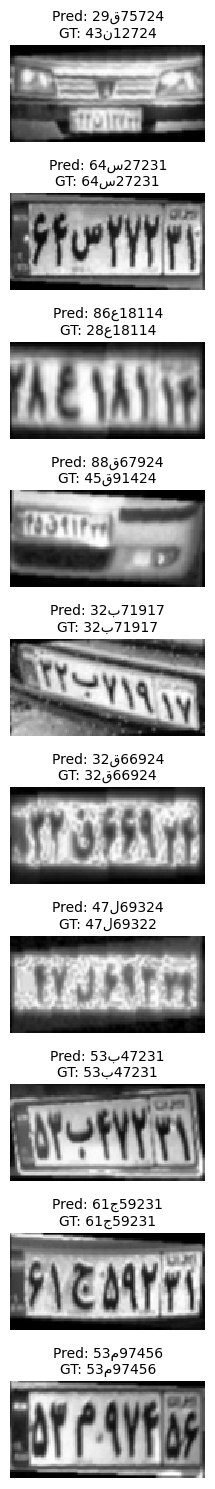

In [72]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import sys
import json
sys.path.append('/content')
from dataloader import test_loader, test_dataset
from model import CRNN

# تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 35
hidden_size = 256
model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3.pth"
vocab_path = "/content/vocab.json"

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# لود مدل
model = CRNN(num_classes, hidden_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# انتخاب 10 نمونه رندوم
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)
images = []
labels = []
predictions = []

# پردازش نمونه‌ها
with torch.no_grad():
    for idx in indices:
        image, label = test_dataset[idx]
        images.append(image)
        label_str = ''.join([reverse_vocab[idx.item()] for idx in label if idx.item() in reverse_vocab])
        labels.append(label_str)
        image = image.unsqueeze(0).to(device)
        output = model(image).softmax(2)
        pred = decode_predictions(output, reverse_vocab)[0]
        predictions.append(pred)

# نمایش تصاویر و اطلاعات
fig, axes = plt.subplots(num_samples, 1, figsize=(5, num_samples * 1.5))  # هر تصویر 1.5 اینچ ارتفاع
if num_samples == 1:
    axes = [axes]  # برای یه تصویر، axes رو لیست کنیم
else:
    axes = axes.ravel()

for i in range(num_samples):
    img = images[i].squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    axes[i].imshow(img, cmap='gray', interpolation='none', aspect='equal')
    axes[i].set_title(f"Pred: {predictions[i]}\nGT: {labels[i]}", fontsize=10)
    axes[i].axis('off')
    axes[i].set_xlim(0, 128)
    axes[i].set_ylim(64, 0)

plt.tight_layout()
plt.show()

In [66]:
pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8698c1aa42bb15797a73580897a9bd60d36a8c7e646967fbab7a69a664becf93
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

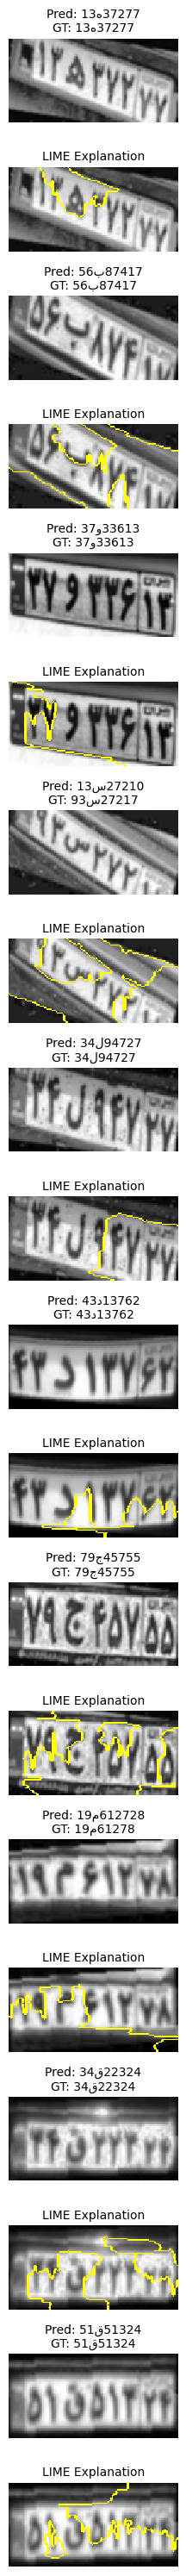

In [75]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import sys
import json
from lime import lime_image
from skimage.segmentation import mark_boundaries
sys.path.append('/content')
from dataloader import test_loader, test_dataset
from model import CRNN

# تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 35
hidden_size = 256
model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth"
vocab_path = "/content/vocab.json"

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# لود مدل
model = CRNN(num_classes, hidden_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# تابع پیش‌بینی برای LIME
def predict_fn(images):
    # تبدیل RGB به grayscale
    images = images.mean(axis=3, keepdims=True)  # میانگین کانال‌ها
    images = torch.tensor(images, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    # نرمالایز کردن مثل دیتالودر
    images = (images - 0.5) / 0.5
    with torch.no_grad():
        outputs = model(images).softmax(2)
    return outputs.mean(dim=1).cpu().numpy()

# انتخاب 10 نمونه رندوم
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)
images = []
labels = []
predictions = []
lime_explanations = []

# پردازش نمونه‌ها
explainer = lime_image.LimeImageExplainer()
for idx in indices:
    image, label = test_dataset[idx]
    images.append(image)
    label_str = ''.join([reverse_vocab[idx.item()] for idx in label if idx.item() in reverse_vocab])
    labels.append(label_str)
    image_tensor = image.unsqueeze(0).to(device)
    output = model(image_tensor).softmax(2)
    pred = decode_predictions(output, reverse_vocab)[0]
    predictions.append(pred)
    # آماده‌سازی تصویر برای LIME
    img = image.squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    img_rgb = np.stack([img]*3, axis=-1)
    explanation = explainer.explain_instance(img_rgb, predict_fn, top_labels=5, num_samples=100)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    lime_explanations.append(mark_boundaries(temp / 255.0, mask))

# نمایش تصاویر و اطلاعات
fig, axes = plt.subplots(num_samples * 2, 1, figsize=(5, num_samples * 3))
for i in range(num_samples):
    # تصویر اصلی
    img = images[i].squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    axes[i*2].imshow(img, cmap='gray', interpolation='none', aspect='equal')
    axes[i*2].set_title(f"Pred: {predictions[i]}\nGT: {labels[i]}", fontsize=10)
    axes[i*2].axis('off')
    axes[i*2].set_xlim(0, 128)
    axes[i*2].set_ylim(64, 0)
    # LIME
    axes[i*2+1].imshow(lime_explanations[i], interpolation='none', aspect='equal')
    axes[i*2+1].set_title("LIME Explanation", fontsize=10)
    axes[i*2+1].axis('off')
    axes[i*2+1].set_xlim(0, 128)
    axes[i*2+1].set_ylim(64, 0)

plt.tight_layout()
plt.show()

In [77]:
!pip install captum


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

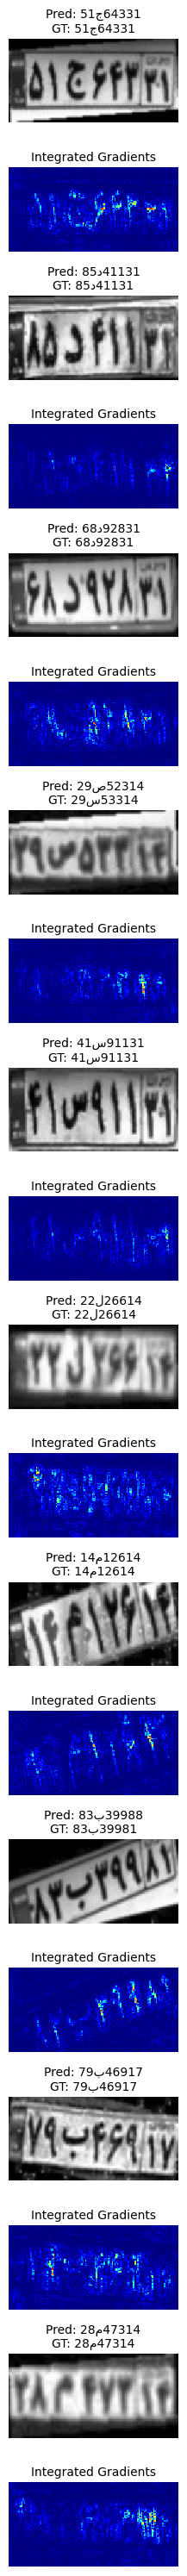

In [79]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import sys
import json
from captum.attr import IntegratedGradients
sys.path.append('/content')
from dataloader import test_loader, test_dataset
from model import CRNN

# تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 35
hidden_size = 256
model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth"
vocab_path = "/content/vocab.json"

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# لود مدل
model = CRNN(num_classes, hidden_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# انتخاب 10 نمونه رندوم
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)
images = []
labels = []
predictions = []
attributions = []

# پردازش نمونه‌ها
ig = IntegratedGradients(model)
for idx in indices:
    image, label = test_dataset[idx]
    images.append(image)
    label_str = ''.join([reverse_vocab[idx.item()] for idx in label if idx.item() in reverse_vocab])
    labels.append(label_str)
    image_tensor = image.unsqueeze(0).to(device)
    image_tensor.requires_grad = True
    # پیش‌بینی
    model.eval()
    with torch.no_grad():
        output = model(image_tensor).softmax(2)
    pred = decode_predictions(output, reverse_vocab)[0]
    predictions.append(pred)
    # محاسبه attribution
    model.train()  # برای RNN backward
    pred_indices = torch.argmax(output, dim=2)[0]
    attr_sum = None
    for t in range(output.size(1)):
        attr = ig.attribute(image_tensor, target=(t, pred_indices[t]), n_steps=50)
        if attr_sum is None:
            attr_sum = attr
        else:
            attr_sum += attr
    attr_sum /= output.size(1)
    attributions.append(attr_sum.squeeze().detach().cpu().numpy())  # اضافه کردن detach
    model.eval()  # برگرد به حالت eval

# نمایش تصاویر و اطلاعات
fig, axes = plt.subplots(num_samples * 2, 1, figsize=(5, num_samples * 3))
for i in range(num_samples):
    # تصویر اصلی
    img = images[i].squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    axes[i*2].imshow(img, cmap='gray', interpolation='none', aspect='equal')
    axes[i*2].set_title(f"Pred: {predictions[i]}\nGT: {labels[i]}", fontsize=10)
    axes[i*2].axis('off')
    axes[i*2].set_xlim(0, 128)
    axes[i*2].set_ylim(64, 0)
    # Integrated Gradients
    attr = np.abs(attributions[i])
    attr = (attr / attr.max()) * 255
    attr = attr.astype(np.uint8)
    axes[i*2+1].imshow(attr, cmap='jet', interpolation='none', aspect='equal')
    axes[i*2+1].set_title("Integrated Gradients", fontsize=10)
    axes[i*2+1].axis('off')
    axes[i*2+1].set_xlim(0, 128)
    axes[i*2+1].set_ylim(64, 0)

plt.tight_layout()
plt.show()

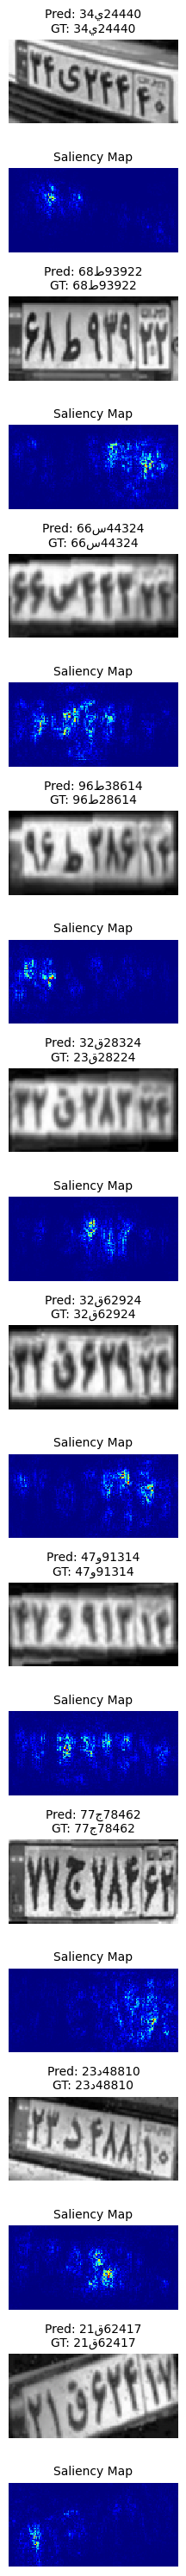

In [82]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import sys
import json
sys.path.append('/content')
from dataloader import test_loader, test_dataset
from model import CRNN

# تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 35
hidden_size = 256
model_path = "/content/drive/MyDrive/Fum/term9/Project_phase2/ocr_v3_p20.pth"
vocab_path = "/content/vocab.json"

# لود وکبیولری
with open(vocab_path, 'r', encoding='utf-8') as f:
    vocab = json.load(f)
reverse_vocab = {v: k for k, v in vocab.items()}

# لود مدل
model = CRNN(num_classes, hidden_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

# تابع دیکدینگ
def decode_predictions(outputs, reverse_vocab):
    _, max_indices = torch.max(outputs, dim=2)
    decoded = []
    for seq in max_indices:
        prev = None
        decoded_seq = []
        for idx in seq:
            idx = idx.item()
            if idx != 0 and idx != prev:
                if idx in reverse_vocab:
                    decoded_seq.append(reverse_vocab[idx])
            prev = idx
        decoded.append(''.join(decoded_seq))
    return decoded

# تابع سالینسی مپ
def compute_saliency_map(model, image, target_class=None):
    model.train()  # برای RNN backward
    image = image.requires_grad_(True)
    output = model(image).softmax(2)
    if target_class is None:
        target_class = torch.argmax(output, dim=2).max()
    score = output[:, :, target_class].mean()
    model.zero_grad()
    score.backward()
    saliency = image.grad.abs().squeeze().cpu().detach().numpy()  # اضافه کردن detach
    saliency = (saliency / saliency.max()) * 255
    return saliency.astype(np.uint8)

# انتخاب 10 نمونه رندوم
num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)
images = []
labels = []
predictions = []
saliency_maps = []

# پردازش نمونه‌ها
for idx in indices:
    image, label = test_dataset[idx]
    images.append(image)
    label_str = ''.join([reverse_vocab[idx.item()] for idx in label if idx.item() in reverse_vocab])
    labels.append(label_str)
    image_tensor = image.unsqueeze(0).to(device)
    # پیش‌بینی
    model.eval()
    with torch.no_grad():
        output = model(image_tensor).softmax(2)
    pred = decode_predictions(output, reverse_vocab)[0]
    predictions.append(pred)
    # سالینسی مپ
    saliency = compute_saliency_map(model, image_tensor)
    saliency_maps.append(saliency)
    model.eval()  # برگرد به حالت eval

# نمایش تصاویر و اطلاعات
fig, axes = plt.subplots(num_samples * 2, 1, figsize=(5, num_samples * 3))
for i in range(num_samples):
    # تصویر اصلی
    img = images[i].squeeze().cpu().numpy()
    img = (img * 0.5 + 0.5) * 255
    img = img.astype(np.uint8)
    axes[i*2].imshow(img, cmap='gray', interpolation='none', aspect='equal')
    axes[i*2].set_title(f"Pred: {predictions[i]}\nGT: {labels[i]}", fontsize=10)
    axes[i*2].axis('off')
    axes[i*2].set_xlim(0, 128)
    axes[i*2].set_ylim(64, 0)
    # سالینسی مپ
    axes[i*2+1].imshow(saliency_maps[i], cmap='jet', interpolation='none', aspect='equal')
    axes[i*2+1].set_title("Saliency Map", fontsize=10)
    axes[i*2+1].axis('off')
    axes[i*2+1].set_xlim(0, 128)
    axes[i*2+1].set_ylim(64, 0)

plt.tight_layout()
plt.show()